In [1]:
from dask.distributed import Client,LocalCluster
from dask_jobqueue import PBSCluster

In [3]:
PROJECT = "er8"

walltime = "01:00:00"
cores = 24
memory = str(4 * cores) + "GB"

cluster = PBSCluster(
    walltime=str(walltime),
    cores=cores,
    memory=str(memory),
    processes=cores,
    job_extra_directives=[
        "-q normal",
        "-P "+PROJECT,
        "-l ncpus="+str(cores),
        "-l mem="+str(memory),
        "-l storage=gdata/xp65+gdata/rv74"
    ],
    local_directory="$TMPDIR",
    job_directives_skip=["select"],
    log_directory="/scratch/ng72/cd3022/tmp/logs"
)

In [4]:
cluster.scale(jobs=1)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.6.42.33:42837,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path

In [6]:
%cd /home/548/cd3022/repos/hot-cloudy/

/home/548/cd3022/repos/hot-cloudy


In [7]:
events = pd.read_csv(
    "hot_cloudy_2015_2024/event_dates_csi0p5_thourly90_counts.csv",
    parse_dates=True,
    index_col=0
)
nulls = pd.read_csv(
    "hot_cloudy_2015_2024/null_event_dates_csi0p5_thourly90_nhours7.csv",
    parse_dates=True,
    index_col=0
)

In [8]:
events

,region,nhours
time,,
2015-11-01,GHOB,2
2015-11-09,GHOB,1
2015-11-25,GADE,1
2015-11-25,GMEL,1
2015-12-07,GADE,1
...,...,...
2024-12-05,GADE,2
2024-12-06,GADE,2
2024-12-16,GMEL,2


In [9]:
# Relevant times to select from himawari data dir
times = []
for hour in range(7):
    for minute in range(0, 60, 10):
        time = f'{hour:02d}{minute:02d}'
        times.append(time)

In [10]:
def get_date_solar(date):
    """
    Return array of ghi for a single date, 1000-1650 AEST

    date: pandas Timestamp
    """
    year = date.year
    month = f'{date.month:02d}'
    day = f'{date.day:02d}'
    
    if date <= pd.Timestamp('2019-03-31'):
        version = 'v1.0'
    else:
        version = 'v1.1'
    dir_path = Path(f'/g/data/rv74/satellite-products/arc/der/himawari-ahi/solar/p1s/{version}/{year}/{month}/{day}/')
    all_files = [f for f in dir_path.glob('*.nc')]
    files = [f for f in all_files if any(f'{t}.nc' in f.name for t in times)]

    solar = xr.open_mfdataset(
        files,
        chunks='auto',
        concat_dim='time',
        combine='nested',
        # data_vars='minimal',
        coords='minimal',
        compat='override',
        parallel=True,
    )
    return solar.surface_global_irradiance

In [11]:
def get_all_dates_solar(dates):
    """
    Return concatenated array of wind speed for all dates

    dates: pandas DateTimeIndex
    """
    da_list = []
    for date in dates:
        solar = get_date_solar(date)
        da_list.append(solar)
    return xr.concat(da_list, dim="time")

In [12]:
regions = np.unique(events["region"])
compute = False

In [13]:
composite_data = {}
for region in regions:
    composite_data[region] = {}

    if compute:
        # Event/null event days for region
        r_events = events[events["region"] == region]
        r_nulls = nulls[nulls["region"] == region]
    
        # Wind speed data
        r_solar_events = get_all_dates_solar(r_events.index)
        r_solar_nulls = get_all_dates_solar(r_nulls.index)
    
        # # Capacity factors
        # r_cf_events = capacity_factor(r_wind_events)
        # r_cf_nulls = capacity_factor(r_wind_nulls)

        # Time-mean
        r_solar_events = r_solar_events.mean("time")
        r_solar_nulls = r_solar_nulls.mean("time")

        # Write to file
        r_solar_events.to_netcdf(
            "hot_cloudy_2015_2024/solar_composite_events_"+region+".nc"
        )
        r_solar_nulls.to_netcdf(
            "hot_cloudy_2015_2024/solar_composite_null_events_"+region+".nc"
        )

    # Read in composite data
    composite_data[region]["events"] = xr.open_mfdataset(
        "hot_cloudy_2015_2024/solar_composite_events_"+region+".nc"
    )
    composite_data[region]["nulls"] = xr.open_mfdataset(
        "hot_cloudy_2015_2024/solar_composite_null_events_"+region+".nc"
    )

In [14]:
import cartopy.crs as ccrs
import cartopy

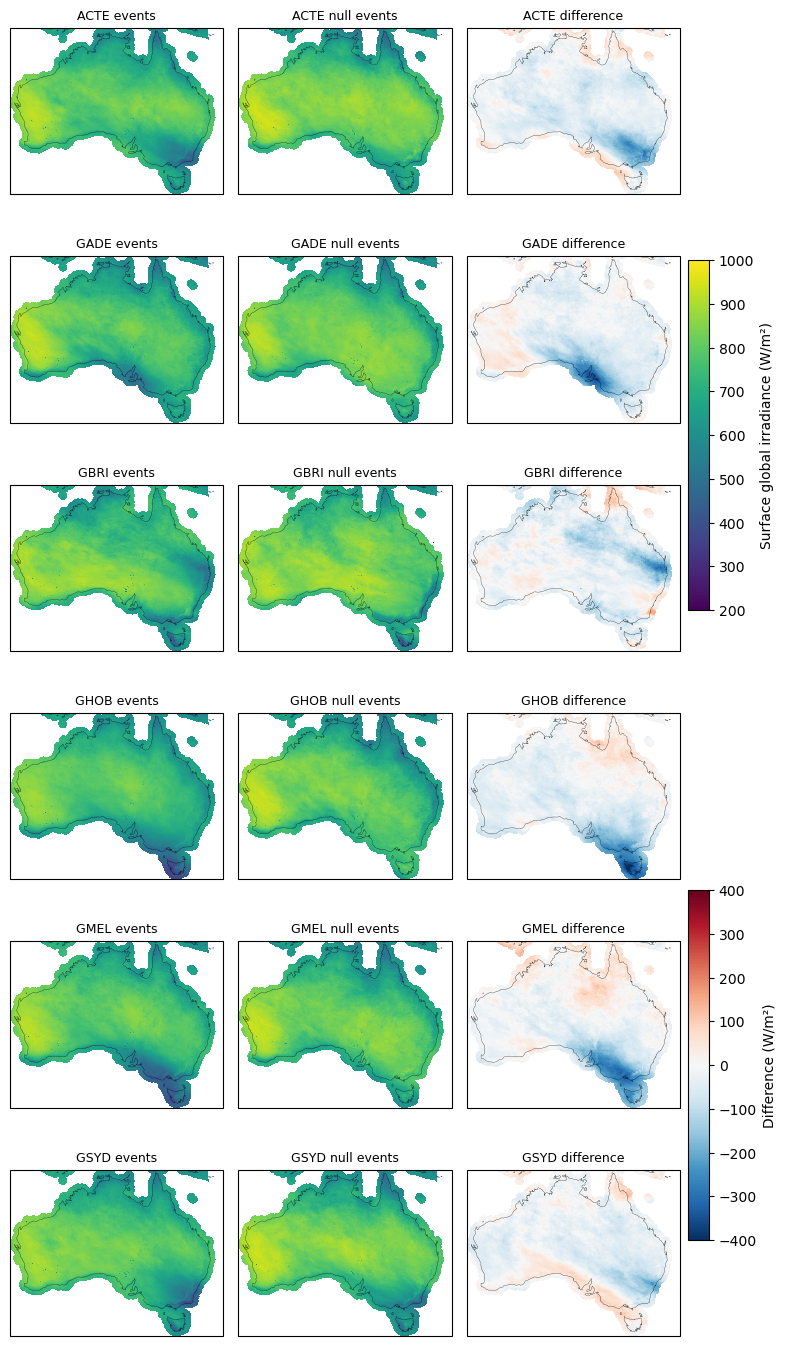

<Figure size 640x480 with 0 Axes>

In [15]:
fig, ax = plt.subplots(6, 3, figsize=(7, 14), subplot_kw={"projection": ccrs.PlateCarree()})

for i, r in enumerate(regions[:]):
    
    im1 = composite_data[r]["events"].surface_global_irradiance.plot(ax=ax[i,0], vmin=200, vmax=1000, add_colorbar=False)
    ax[i,0].set_title(r+" events", fontsize=9)
    
    composite_data[r]["nulls"].surface_global_irradiance.plot(ax=ax[i,1], vmin=200, vmax=1000, add_colorbar=False)
    ax[i,1].set_title(r+" null events", fontsize=9)

    diff = composite_data[r]["events"] - composite_data[r]["nulls"]
    im3 = diff.surface_global_irradiance.plot(ax=ax[i,2], vmin=-400, vmax=400, cmap="RdBu_r", add_colorbar=False)
    ax[i,2].set_title(r+" difference", fontsize=9)

for a in ax.flatten():
    a.coastlines(lw=.2)
    a.set_xlabel("")
    a.set_xticklabels([])
    a.set_ylabel("")
    a.set_yticklabels([])

plt.tight_layout()

# position = [left, bottom, width, height]
cax1 = fig.add_axes([0.99, 0.55, 0.03, 0.25])  # upper colorbar
cax2 = fig.add_axes([0.99, 0.10, 0.03, 0.25])  # lower colorbar

cbar1 = fig.colorbar(im1, cax=cax1)
cbar1.set_label("Surface global irradiance (W/m²)")

# Right colorbar for third column
cbar2 = fig.colorbar(im3, cax=cax2)
cbar2.set_label("Difference (W/m²)")

plt.show()

plt.savefig("figs/solar_composites.png", format="png", dpi=200)